# Fase 2.2 — Modelo LSTM

**Thesis:** Comparativa de algoritmos para la predicción de la demanda eléctrica  
**Author:** Antonio Navarro  

This notebook:
1. Loads the feature CSVs produced in Fase 1
2. Scales features with MinMaxScaler (fitted on train)
3. Builds sliding-window sequences (lookback=168h, horizon=24h)
4. Trains a 2-layer stacked LSTM with EarlyStopping
5. Evaluates on the test set (stride=24 → non-overlapping daily blocks)
6. Saves predictions and metrics

In [1]:
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ── Colab: clone or update the repo, then cd into it ──────────────────────────
REPO_NAME = "pred_demanda"
REPO_URL  = "https://github.com/antonionc/pred_demanda.git"

if os.path.exists("data_utils.py"):
    !git pull
elif os.path.isdir(REPO_NAME):
    %cd {REPO_NAME}
    !git pull
elif os.path.exists(f"/content/{REPO_NAME}"):
    %cd /content/{REPO_NAME}
    !git pull
elif os.path.exists("/content"):
    !git clone {REPO_URL}
    %cd {REPO_NAME}
# ──────────────────────────────────────────────────────────────────────────────

sys.path.insert(0, os.path.abspath('.'))
import data_utils as du

# Mount Google Drive in Colab and create persistent links for data/, cache/, saved_models/
du.setup_colab_drive()

np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3})

print(f'TensorFlow {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')

Cloning into 'pred_demanda'...
remote: Enumerating objects: 132, done.
remote: Counting objects: 100% (132/132), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 132 (delta 76), reused 75 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (132/132), 3.84 MiB | 23.24 MiB/s, done.
Resolving deltas: 100% (76/76), done.
/content/pred_demanda
[Colab] Requesting scoped access to Google Drive ('drive.file')...


  [DriveSync] Downloading data/fig_stl_decomposition.png...
  [DriveSync] Downloading data/fig_data_split.png...
  [DriveSync] Downloading data/fig_lstm_week.png...
  [DriveSync] Downloading data/fig_sarimax_residuals.png...
  [DriveSync] Downloading data/fig_pearson_correlation.png...
  [DriveSync] Downloading data/predictions_ttm_zeroshot.csv...
  [DriveSync] Downloading data/fig_acf_pacf.png...
  [DriveSync] Downloading data/metrics_ttm_fewshot.json...
  [DriveSync] Downloading data/fig_ttm_finetune.png...
  [DriveSync] Downloading data/hourly_features_full.csv...
  [DriveSync] Downloading data/predictions_ttm_fewshot.csv...
  [DriveSync] Downloading data/features_train.csv...
  [DriveSync] Downloading data/fig_boxcox.png...
  [DriveSync] Downloading data/fig_raw_demand.png...
  [DriveSync] Downloading data/predictions_sarimax.csv...
  [DriveSync] Downloading data/fig_lstm_training.png...
  [DriveSync] Downloading data/metrics_lstm.json...
  [DriveSync] Downloading data/fig_lstm_res

## 1 · Load data

In [2]:
df_train = pd.read_csv('data/features_train.csv', parse_dates=['datetime'])
df_val   = pd.read_csv('data/features_val.csv',   parse_dates=['datetime'])
df_test  = pd.read_csv('data/features_test.csv',  parse_dates=['datetime'])

print(f'Train: {len(df_train):,}  Val: {len(df_val):,}  Test: {len(df_test):,}')

# Feature columns — all numeric except datetime
FEATURE_COLS = [c for c in df_train.columns if c != 'datetime']
TARGET_COL   = 'demand_mw'
print(f'Features: {len(FEATURE_COLS)}')

Train: 29,259  Val: 9,753  Test: 9,754
Features: 49


## 2 · Normalise with MinMaxScaler (fit on train)

In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(df_train[FEATURE_COLS])

train_scaled = scaler.transform(df_train[FEATURE_COLS])
val_scaled   = scaler.transform(df_val[FEATURE_COLS])
test_scaled  = scaler.transform(df_test[FEATURE_COLS])

# Target column index (needed for inverse-transform later)
target_idx = FEATURE_COLS.index(TARGET_COL)

train_feat = train_scaled
train_tgt  = train_scaled[:, target_idx]

val_feat   = val_scaled
val_tgt    = val_scaled[:, target_idx]

test_feat  = test_scaled
test_tgt   = test_scaled[:, target_idx]

print(f'Scaled arrays — train: {train_feat.shape}  val: {val_feat.shape}  test: {test_feat.shape}')

Scaled arrays — train: (29259, 49)  val: (9753, 49)  test: (9754, 49)


## 3 · Build sliding-window sequences

In [4]:
LOOKBACK = 168   # 1 week in hours
HORIZON  = 24    # 24h ahead forecast

# Training: stride=1 (dense overlapping windows for maximum data)
X_train, y_train = du.make_sequences(train_feat, train_tgt, LOOKBACK, HORIZON, stride=1)

# Validation: stride=1
X_val, y_val = du.make_sequences(val_feat, val_tgt, LOOKBACK, HORIZON, stride=1)

# Test: stride=24 → non-overlapping daily blocks
X_test, y_test = du.make_sequences(test_feat, test_tgt, LOOKBACK, HORIZON, stride=HORIZON)

print(f'X_train {X_train.shape}  y_train {y_train.shape}')
print(f'X_val   {X_val.shape}    y_val   {y_val.shape}')
print(f'X_test  {X_test.shape}   y_test  {y_test.shape}')

X_train (29068, 168, 49)  y_train (29068, 24)
X_val   (9562, 168, 49)    y_val   (9562, 24)
X_test  (399, 168, 49)   y_test  (399, 24)


## 4 · Build LSTM model

In [5]:
def build_lstm(input_shape, horizon):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape,
             dropout=0.2, recurrent_dropout=0.0),
        Dropout(0.2),
        LSTM(64, return_sequences=False,
             dropout=0.2, recurrent_dropout=0.0),
        Dropout(0.2),
        Dense(horizon, activation='linear'),
    ])
    model.compile(
        optimizer = Adam(learning_rate=1e-3),
        loss      = 'mse',
        metrics   = ['mae'],
    )
    return model

model = build_lstm(
    input_shape = (LOOKBACK, X_train.shape[2]),
    horizon     = HORIZON,
)
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 128)       │        91,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,104 (555.09 KB)

 Trainable params: 142,104 (555.09 KB)

 Non-trainable params: 0 (0.00 B)

## 5 · Train

In [6]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1),
    ModelCheckpoint('saved_models/lstm_best.keras', monitor='val_loss',
                    save_best_only=True, verbose=0),
]

print('Training…')
t0 = time.time()

history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = 150,
    batch_size      = 128,
    callbacks       = callbacks,
    shuffle         = False,
    verbose         = 1,
)

train_time = time.time() - t0
print(f'\nTraining completed in {train_time:.1f}s  ({train_time/60:.1f} min)')
print(f'Best val_loss: {min(history.history["val_loss"]):.6f}')

Training…
Epoch 1/150
228/228 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - loss: 0.0468 - mae: 0.1688 - val_loss: 0.0261 - val_mae: 0.1292 - learning_rate: 0.0010
Epoch 2/150
228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0247 - mae: 0.1239 - val_loss: 0.0128 - val_mae: 0.0864 - learning_rate: 0.0010
Epoch 3/150
228/228 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0181 - mae: 0.1058 - val_loss: 0.0103 - val_mae: 0.0776 - learning_rate: 0.0010
Epoch 4/150
228/228 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.0149 - mae: 0.0957 - val_loss: 0.0075 - val_mae: 0.0666 - learning_rate: 0.0010
Epoch 5/150
228/228 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0125 - mae: 0.0877 - val_loss: 0.0067 - val_mae: 0.0624 - learning_rate: 0.0010
Epoch 6/150
228/228 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0112 - mae: 0.0827 - val_loss: 0.0059 - val_mae: 0.0593 - learning_rate: 0.0010
Epoch 7/150
228/228 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0103 - mae: 0.0795 - val_loss: 0.0059 - val_mae: 0.0589 - lea

Figure saved → data/fig_lstm_training.png


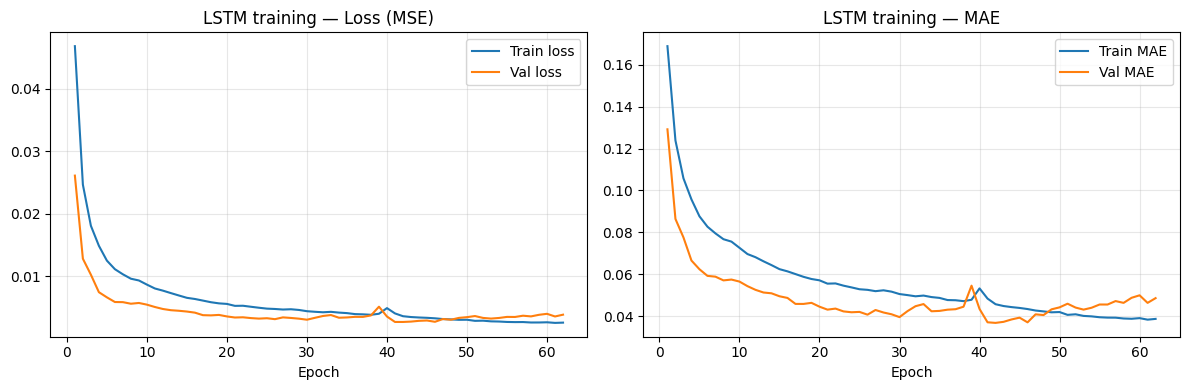

In [7]:
du.plot_training_history(
    history,
    title     = 'LSTM training',
    save_path = 'data/fig_lstm_training.png',
)

## 6 · Inference on test set

In [8]:
t0 = time.time()
y_pred_scaled = model.predict(X_test, verbose=0)
inference_time = time.time() - t0
print(f'Inference time: {inference_time:.2f}s  ({inference_time*1000/len(X_test):.1f}ms/sample)')

# Inverse-transform predictions and actuals back to MW
# We only scaled one column; use scaler's min/max for that column
t_min = scaler.data_min_[target_idx]
t_max = scaler.data_max_[target_idx]

y_pred_mw = y_pred_scaled * (t_max - t_min) + t_min
y_true_mw = y_test        * (t_max - t_min) + t_min

# Flatten for metric computation
y_pred_flat = y_pred_mw.ravel()
y_true_flat = y_true_mw.ravel()

# Corresponding datetimes (stride=24, first date of each window + LOOKBACK offset)
test_datetimes = df_test['datetime'].values
dates_flat = np.concatenate([
    test_datetimes[LOOKBACK + i * HORIZON : LOOKBACK + i * HORIZON + HORIZON]
    for i in range(len(X_test))
])
print(f'Forecast points: {len(y_pred_flat):,}')

Inference time: 0.54s  (1.4ms/sample)
Forecast points: 9,576


## 7 · Metrics

In [9]:
metrics = du.compute_metrics(y_true_flat, y_pred_flat, label='LSTM')
metrics['train_s']     = train_time
metrics['inference_s'] = inference_time

[LSTM] MAPE=5.747%  RMSE=1694.0 MW  MAE=1204.1 MW


## 8 · Plots

Figure saved → data/fig_lstm_test.png


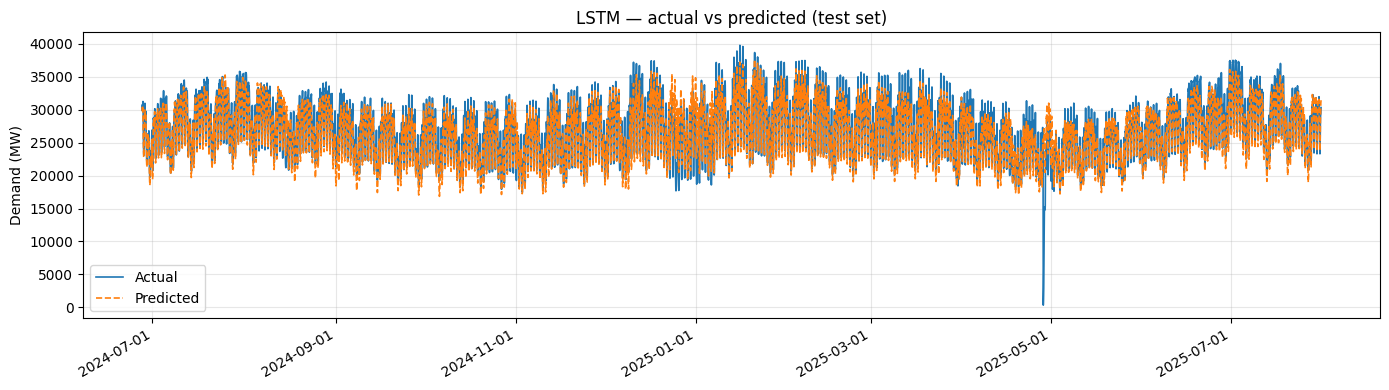

In [10]:
du.plot_predictions(
    y_true_flat, y_pred_flat,
    title     = 'LSTM — actual vs predicted (test set)',
    dates     = pd.to_datetime(dates_flat),
    save_path = 'data/fig_lstm_test.png',
)

Figure saved → data/fig_lstm_week.png


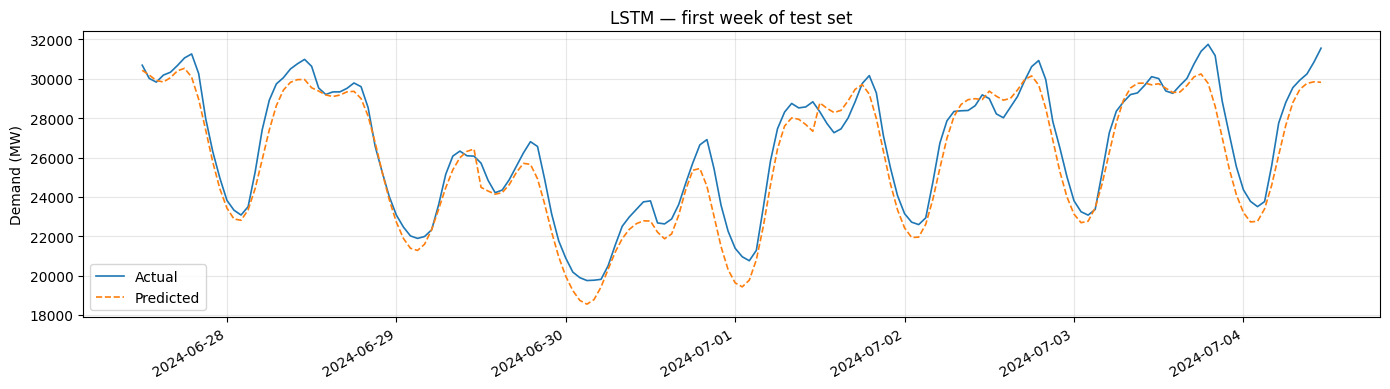

In [11]:
# Zoom into first week
idx = slice(0, 168)
du.plot_predictions(
    y_true_flat[idx], y_pred_flat[idx],
    title     = 'LSTM — first week of test set',
    dates     = pd.to_datetime(dates_flat[idx]),
    save_path = 'data/fig_lstm_week.png',
)

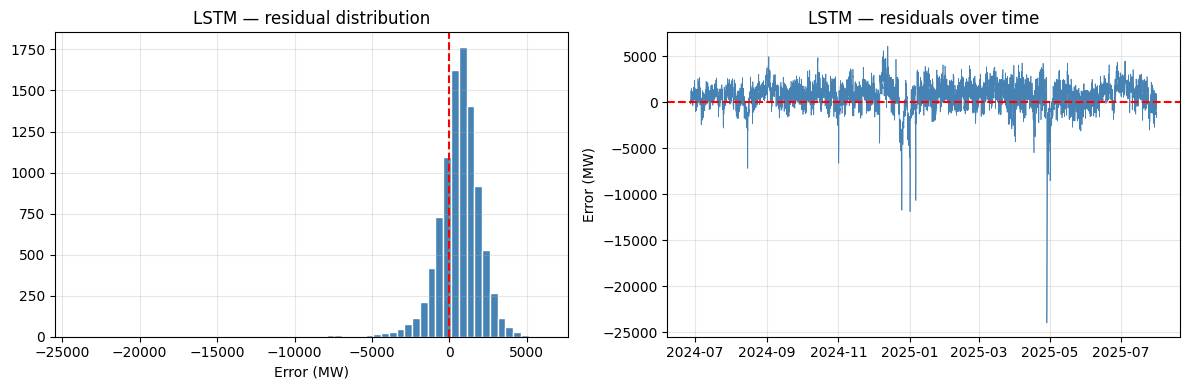

In [12]:
# Error distribution
errors = y_true_flat - y_pred_flat
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(errors, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('LSTM — residual distribution')
axes[0].set_xlabel('Error (MW)')

axes[1].plot(pd.to_datetime(dates_flat), errors, linewidth=0.5, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('LSTM — residuals over time')
axes[1].set_ylabel('Error (MW)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.savefig('data/fig_lstm_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

## 9 · Save predictions and metrics

In [13]:
import json

df_preds = pd.DataFrame({
    'datetime': dates_flat,
    'y_true':   y_true_flat,
    'y_pred':   y_pred_flat,
})
df_preds.to_csv('data/predictions_lstm.csv', index=False)

with open('data/metrics_lstm.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(f'Saved {len(df_preds):,} rows → data/predictions_lstm.csv')
print(f'Saved metrics → data/metrics_lstm.json')
print(metrics)
# Sync outputs to Google Drive (if in Colab)
du.sync_to_drive()


Saved 9,576 rows → data/predictions_lstm.csv
Saved metrics → data/metrics_lstm.json
{'mape': 5.746937221609684, 'rmse': 1694.04475651152, 'mae': 1204.0516157060108, 'train_s': 419.2322688102722, 'inference_s': 0.542412281036377}
  [DriveSync] Uploading data/fig_ttm_fewshot_week.png to Drive...
  [DriveSync] Uploading data/fig_seasonality.png to Drive...
  [DriveSync] Uploading data/metrics_ttm_fewshot.json to Drive...
  [DriveSync] Uploading data/fig_lstm_week.png to Drive...
  [DriveSync] Uploading data/fig_acf_pacf.png to Drive...
  [DriveSync] Uploading data/fig_raw_demand.png to Drive...
  [DriveSync] Uploading data/features_val.csv to Drive...
  [DriveSync] Uploading data/fig_ttm_finetune.png to Drive...
  [DriveSync] Uploading data/predictions_sarimax.csv to Drive...
  [DriveSync] Uploading data/fig_lstm_residuals.png to Drive...
  [DriveSync] Uploading data/fig_stl_decomposition.png to Drive...
  [DriveSync] Uploading data/metrics_ttm_zeroshot.json to Drive...
  [DriveSync] Uplo

True

## Summary

| Metric | Value |
|--------|-------|
| MAPE   | … % |
| RMSE   | … MW |
| MAE    | … MW |
| Training time | … s |
| Inference time | … s |

Next step → `fase2_3_ttm.ipynb`